# Exp Q — Nível de Base de $R_{\text{comp}}$: Convergência ou Divergência?

**Observação (T. Bandeira):** no gráfico de sobreposição de $R_{\text{primo}}$ e $R_{\text{comp}}$,
os vales dos primos ficam próximos de zero enquanto os vales dos compostos
parecem convergir para um valor positivo acima de zero.

**Pergunta:** esse nível de base de $R_{\text{comp}}$ converge para uma constante
à medida que $N \to \infty$? Se sim, primos seriam distinguíveis de pares
compostos pela posição relativa ao nível de base.

**Medição:** para cada N, calcular:
- Nível de base de $R_{\text{primo}}$: mediana dos vales (mínimos locais)
- Nível de base de $R_{\text{comp}}$: mediana dos vales
- Razão entre os dois níveis
- Evolução com N

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime
from scipy.signal import argrelmin, argrelmax

plt.style.use('dark_background')
C_PRIME     = '#00FFB2'
C_COMPOSITE = '#FF4466'
C_BASE      = '#FFB300'
BG          = '#0D0D1A'

def S_m(t, m):
    return -np.cos(t * math.log(m)) / math.sqrt(m)

def f_m(m):
    return math.log(m) / (2 * math.pi)

def construir_espectros(N, T_MAX=1000, dt=0.05):
    t     = np.arange(0.1, T_MAX, dt)
    freqs = np.fft.rfftfreq(len(t), d=dt)

    primos    = [m for m in range(2, N+1) if isprime(m)]
    compostos = [m for m in range(2, N+1) if not isprime(m)]

    R_primo = sum(S_m(t, p) for p in primos)
    R_comp  = sum(S_m(t, c) for c in compostos)

    F_primo = np.abs(np.fft.rfft(R_primo)) * dt
    F_comp  = np.abs(np.fft.rfft(R_comp))  * dt

    # Recortar região relevante: f in [f(2), f(N)]
    f_lo = f_m(2)   - 0.01
    f_hi = f_m(N)   + 0.02
    mask = (freqs >= f_lo) & (freqs <= f_hi)

    return freqs[mask], F_primo[mask], F_comp[mask], primos, compostos

def nivel_base(F, order=5):
    """Mediana dos mínimos locais — nível de base do espectro."""
    idx_min = argrelmin(F, order=order)[0]
    if len(idx_min) == 0:
        return np.min(F)
    return np.median(F[idx_min])

def nivel_pico(F, order=5):
    """Mediana dos máximos locais."""
    idx_max = argrelmax(F, order=order)[0]
    if len(idx_max) == 0:
        return np.max(F)
    return np.median(F[idx_max])

print('Pronto.')

Pronto.


## 1. Visualização para N=150: picos, vales e nível de base

R_primo:  base=1.8040  pico_med=65.1814  médio=33.4927
R_comp:   base=4.3182  pico_med=70.5207  médio=37.4194
Razão médio_comp/médio_primo = 1.12


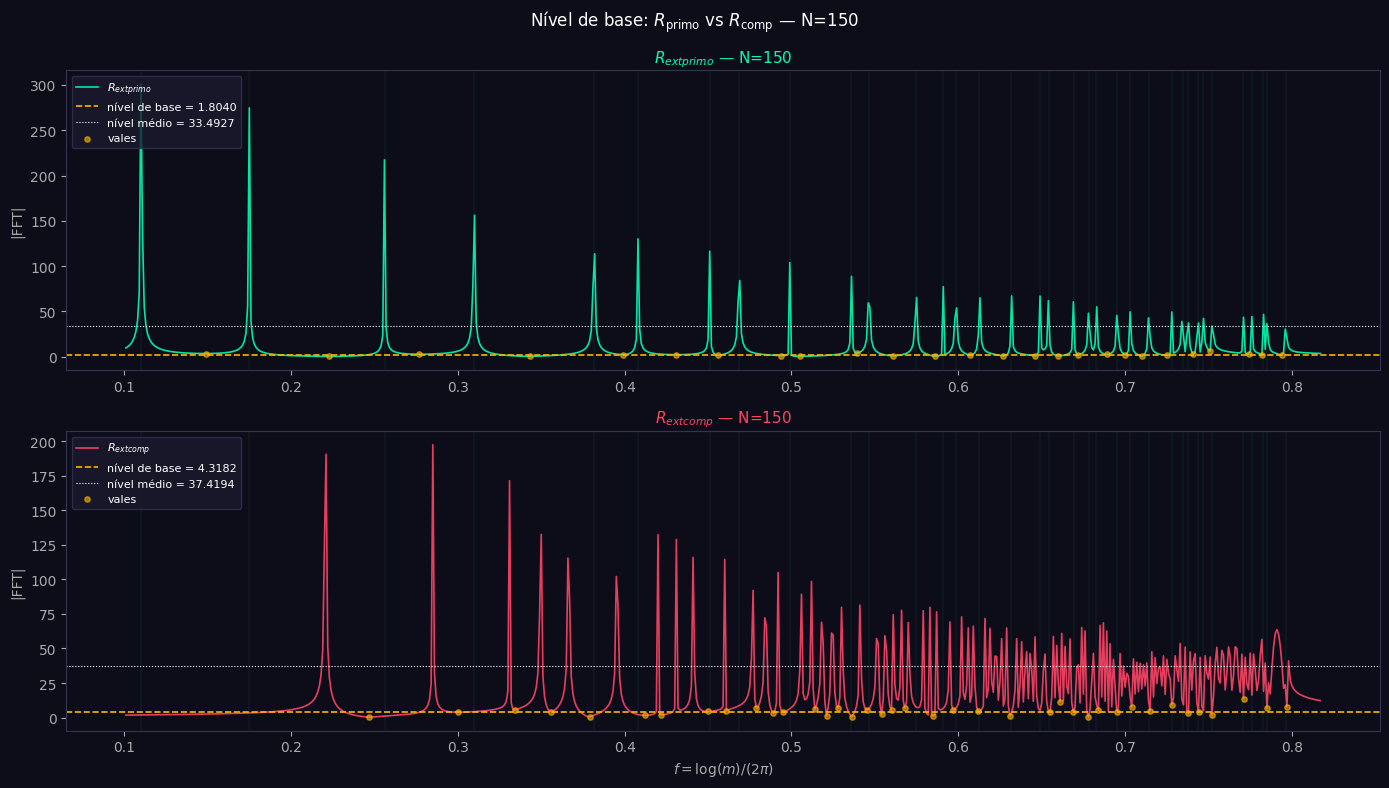

In [ ]:
fqs, Fp, Fc, primos, compostos = construir_espectros(150)

# Nível de base
base_p = nivel_base(Fp)
base_c = nivel_base(Fc)
pico_p = nivel_pico(Fp)
pico_c = nivel_pico(Fc)
medio_p = (base_p + pico_p) / 2
medio_c = (base_c + pico_c) / 2

print(f'R_primo:  base={base_p:.4f}  pico_med={pico_p:.4f}  médio={medio_p:.4f}')
print(f'R_comp:   base={base_c:.4f}  pico_med={pico_c:.4f}  médio={medio_c:.4f}')
print(f'Razão médio_comp/médio_primo = {medio_c/medio_p:.2f}')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.patch.set_facecolor(BG)

for ax, (F, color, label, base, medio) in zip(axes, [
    (Fp, C_PRIME,     '$R_{\text{primo}}$', base_p, medio_p),
    (Fc, C_COMPOSITE, '$R_{\text{comp}}$',  base_c, medio_c),
]):
    ax.set_facecolor(BG)
    ax.plot(fqs, F, color=color, lw=1.2, alpha=0.9, label=label)

    # nível de base e médio
    ax.axhline(base,  color=C_BASE,  lw=1.2, ls='--',
               label=f'nível de base = {base:.4f}')
    ax.axhline(medio, color='white', lw=0.8, ls=':',
               label=f'nível médio = {medio:.4f}')

    # marcar mínimos locais
    idx_min = argrelmin(F, order=5)[0]
    ax.scatter(fqs[idx_min], F[idx_min], color=C_BASE,
               s=15, zorder=5, alpha=0.6, label='vales')

    # marcar posições dos primos
    for p in primos:
        ax.axvline(f_m(p), color=C_PRIME, lw=0.3, alpha=0.2)

    ax.set_ylabel('|FFT|', color='#AAAAAA')
    ax.set_title(f'{label} — N=150', color=color, fontsize=11)
    ax.legend(facecolor='#1A1A2E', edgecolor='#333355',
              labelcolor='white', fontsize=8)
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values(): spine.set_edgecolor('#333355')

axes[1].set_xlabel('$f = \\log(m)/(2\\pi)$', color='#AAAAAA')
plt.suptitle('Nível de base: $R_{\\text{primo}}$ vs $R_{\\text{comp}}$ — N=150',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Evolução do nível de base com N crescente

In [ ]:
Ns = [30, 50, 80, 100, 150, 200, 300, 500]

base_primos = []
base_comps  = []
medio_primos = []
medio_comps  = []
razoes       = []

for Nv in Ns:
    print(f'N={Nv}...')
    fqs_v, Fp_v, Fc_v, _, _ = construir_espectros(Nv)
    bp = nivel_base(Fp_v)
    bc = nivel_base(Fc_v)
    mp = nivel_pico(Fp_v)
    mc = nivel_pico(Fc_v)
    med_p = (bp + mp) / 2
    med_c = (bc + mc) / 2
    base_primos.append(bp)
    base_comps.append(bc)
    medio_primos.append(med_p)
    medio_comps.append(med_c)
    razoes.append(med_c / med_p if med_p > 0 else 0)
    print(f'  base_primo={bp:.4f}  base_comp={bc:.4f}  '
          f'médio_primo={med_p:.4f}  médio_comp={med_c:.4f}  '
          f'razão={med_c/med_p:.2f}')

print('\nPronto.')

N=30...
  base_primo=1.9231  base_comp=2.6721  médio_primo=62.6883  médio_comp=56.5180  razão=0.90
N=50...
  base_primo=1.7944  base_comp=3.7194  médio_primo=52.8249  médio_comp=48.9646  razão=0.93
N=80...
  base_primo=1.6161  base_comp=3.8042  médio_primo=41.2391  médio_comp=41.9559  razão=1.02
N=100...
  base_primo=1.4431  base_comp=4.0799  médio_primo=34.4822  médio_comp=41.6509  razão=1.21
N=150...
  base_primo=1.8040  base_comp=4.3182  médio_primo=33.4927  médio_comp=37.4194  razão=1.12
N=200...
  base_primo=1.5482  base_comp=5.0476  médio_primo=30.6352  médio_comp=36.8609  razão=1.20
N=300...
  base_primo=1.8622  base_comp=5.6670  médio_primo=25.9782  médio_comp=35.4856  razão=1.37
N=500...
  base_primo=2.1511  base_comp=6.8981  médio_primo=22.6420  médio_comp=33.1737  razão=1.47

Pronto.


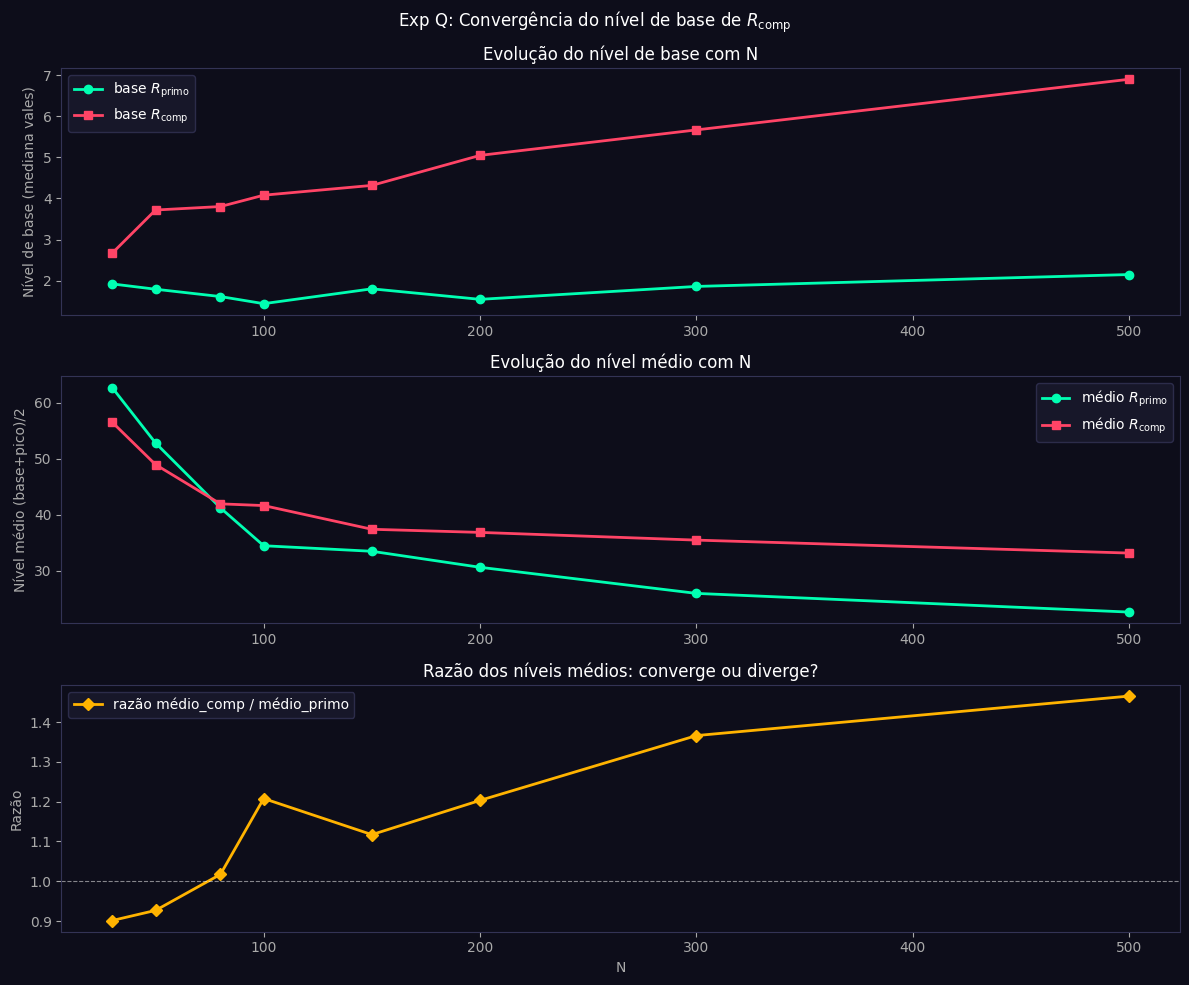

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.patch.set_facecolor(BG)

# Painel 1: nível de base
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(Ns, base_primos, color=C_PRIME,     lw=2, marker='o', ms=6,
        label='base $R_{\\text{primo}}$')
ax.plot(Ns, base_comps,  color=C_COMPOSITE, lw=2, marker='s', ms=6,
        label='base $R_{\\text{comp}}$')
ax.set_ylabel('Nível de base (mediana vales)', color='#AAAAAA')
ax.set_title('Evolução do nível de base com N', color='white')
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# Painel 2: nível médio (base+pico)/2
ax = axes[1]
ax.set_facecolor(BG)
ax.plot(Ns, medio_primos, color=C_PRIME,     lw=2, marker='o', ms=6,
        label='médio $R_{\\text{primo}}$')
ax.plot(Ns, medio_comps,  color=C_COMPOSITE, lw=2, marker='s', ms=6,
        label='médio $R_{\\text{comp}}$')
ax.set_ylabel('Nível médio (base+pico)/2', color='#AAAAAA')
ax.set_title('Evolução do nível médio com N', color='white')
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# Painel 3: razão médio_comp / médio_primo
ax = axes[2]
ax.set_facecolor(BG)
ax.plot(Ns, razoes, color=C_BASE, lw=2, marker='D', ms=6,
        label='razão médio_comp / médio_primo')
ax.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('N', color='#AAAAAA')
ax.set_ylabel('Razão', color='#AAAAAA')
ax.set_title('Razão dos níveis médios: converge ou diverge?', color='white')
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.suptitle('Exp Q: Convergência do nível de base de $R_{\\text{comp}}$',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Estimativa analítica do nível de base

O nível de base de $R_{\text{comp}}$ é determinado pela soma das contribuições
de todos os compostos fora das suas frequências próprias. Para um composto
$c = p^a q^b \dots$, sua contribuição em frequências $f \neq f_c$ é:

$$\langle S_c(t), e^{2\pi i f t} \rangle \approx 0 \quad (\text{ortogonalidade})$$

mas a soma de muitos compostos cria um "ruído de fundo" proporcional a:

$$B_N = \sum_{c \le N,\, c \text{ composto}} \frac{1}{\sqrt{c}} \cdot \frac{1}{T_{\max}}$$

Esta soma cresce como $\sqrt{N}$ (pela aproximação integral $\int_2^N x^{-1/2} dx \sim 2\sqrt{N}$),
mas é dividida por $T_{\max}$ fixo. Se $T_{\max}$ for fixo, o nível de base
**cresce** com N. Se $T_{\max} \propto N$, o nível de base **converge**.

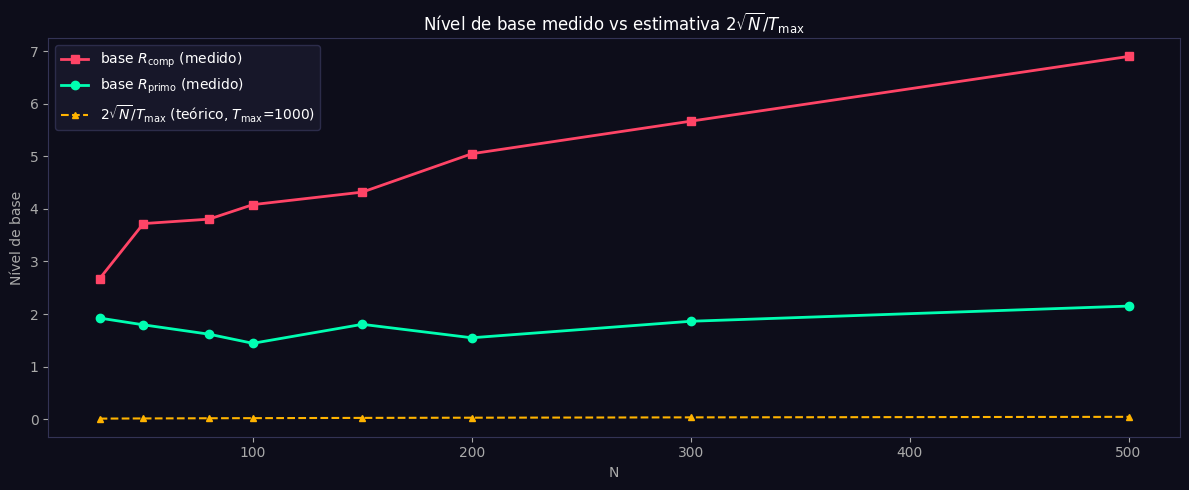


Comparação:
     N   base_comp(med)    2√N/T_max    razão
------------------------------------------------
    30          2.67213      0.01095   243.93
    50          3.71944      0.01414   263.00
    80          3.80415      0.01789   212.66
   100          4.07995      0.02000   204.00
   150          4.31819      0.02449   176.29
   200          5.04762      0.02828   178.46
   300          5.66703      0.03464   163.59
   500          6.89812      0.04472   154.25


In [ ]:
# Verificar a estimativa analítica B_N ~ 2*sqrt(N) / T_max
T_MAX = 1000
B_teorico = [2*math.sqrt(Nv) / T_MAX for Nv in Ns]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(Ns, base_comps,  color=C_COMPOSITE, lw=2, marker='s', ms=6,
        label='base $R_{\\text{comp}}$ (medido)')
ax.plot(Ns, base_primos, color=C_PRIME,     lw=2, marker='o', ms=6,
        label='base $R_{\\text{primo}}$ (medido)')
ax.plot(Ns, B_teorico,   color=C_BASE,      lw=1.5, ls='--', marker='^', ms=5,
        label=f'$2\\sqrt{{N}}/T_{{\\max}}$ (teórico, $T_{{\\max}}$={T_MAX})')

ax.set_xlabel('N', color='#AAAAAA')
ax.set_ylabel('Nível de base', color='#AAAAAA')
ax.set_title('Nível de base medido vs estimativa $2\\sqrt{N}/T_{\\max}$',
             color='white')
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white')
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')
plt.tight_layout()
plt.show()

print('\nComparação:')
print(f'{"N":>6} {"base_comp(med)":>16} {"2√N/T_max":>12} {"razão":>8}')
print('-'*48)
for Nv, bc, bt in zip(Ns, base_comps, B_teorico):
    print(f'{Nv:>6} {bc:>16.5f} {bt:>12.5f} {bc/bt:>8.2f}')

## Interpretação

**Se o nível de base de $R_{\text{comp}}$ cresce com N:**  
A separação primo/composto via nível de base só funciona para N fixo — não é um classificador assintótico.

**Se converge para uma constante:**  
Existe um limiar natural que separa primos (nível baixo) de compostos (nível alto) — o que tornaria os pares entre primos distinguíveis pela posição relativa ao nível de base.

**A estimativa analítica** sugere que com $T_{\max}$ fixo o nível cresce como $\sqrt{N}$. Se $T_{\max} \propto N$ (como prescrito na Nota 28), o nível de base se estabiliza. Isso conecta a observação dos vales com a necessidade de $T_{\max}$ crescente — o mesmo gargalo da dicotomia.

---
*Exp Q — T. Bandeira, 2026*